In [545]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [546]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"
response = requests.get(url)
data = response.json()
print(response.status_code)

200


In [547]:
df = pd.DataFrame(data['items'])
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76124,2927,197622,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34358,2396,164426,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,22075,13,89785,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15275,52,82662,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15620,27,74149,master,1.0


In [548]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [549]:
df.shape

(100, 82)

In [550]:
columns = ['name', 'owner', 'language', 'stargazers_count',
'forks_count', 'watchers_count', 'open_issues_count',
'created_at', 'updated_at', 'license']

df = df[columns]

In [551]:
df.head()

,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197622,76124,197622,2927,2015-11-07T01:19:20Z,2026-08-25T14:05:21Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164426,34358,164426,2396,2018-10-29T13:56:00Z,2026-08-25T14:19:21Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89785,22075,89785,13,2021-03-03T01:34:05Z,2026-08-25T13:56:26Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82662,15275,82662,52,2018-08-21T11:20:39Z,2026-08-25T13:43:12Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74149,15620,74149,27,2014-07-15T19:11:19Z,2026-08-25T13:52:55Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [552]:
owner_list = []
for item in df["owner"]:
    if type(item) == dict and "login" in item:
        owner_list.append(item["login"])
    else:
        owner_list.append("Unknown")
df["owner"] = owner_list

license_list = []
for item in df["license"]:
    if type(item) == dict and "name" in item:
        license_list.append(item["name"])
    else:
        license_list.append("None")
df["license"] = license_list

In [553]:
print(df.isnull().sum())

name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license               0
dtype: int64


In [554]:
df['language'] = df['language'].fillna('Unknown')

In [555]:
print(df.isnull().sum())

name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


In [556]:
df = df.drop_duplicates()

In [557]:
df.duplicated().sum()

np.int64(0)

In [558]:
df['created_at'] = pd.to_datetime(df['created_at']).dt.date

In [559]:
df['updated_at'] = pd.to_datetime(df['updated_at']).dt.date

In [560]:
df = df.rename(columns={
    'stargazers_count': 'stars',
    'forks_count': 'forks',
    'watchers_count': 'watchers',
    'open_issues_count': 'open_issues',
    'created_at': 'created_date',
    'updated_at': 'updated_date'
})

In [561]:
df.head()

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197622,76124,197622,2927,2015-11-07,2026-08-25,Apache License 2.0
1,transformers,huggingface,Python,164426,34358,164426,2396,2018-10-29,2026-08-25,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89785,22075,89785,13,2021-03-03,2026-08-25,MIT License
3,funNLP,fighting41love,Python,82662,15275,82662,52,2018-08-21,2026-08-25,None
4,awesome-machine-learning,josephmisiti,Python,74149,15620,74149,27,2014-07-15,2026-08-25,Other


In [562]:
df.to_csv('github_projects.csv', index=False)

In [563]:
check_df = pd.read_csv('github_projects.csv')
check_df.head()
check_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          100 non-null    object
 1   owner         100 non-null    object
 2   language      100 non-null    object
 3   stars         100 non-null    int64 
 4   forks         100 non-null    int64 
 5   watchers      100 non-null    int64 
 6   open_issues   100 non-null    int64 
 7   created_date  100 non-null    object
 8   updated_date  100 non-null    object
 9   license       78 non-null     object
dtypes: int64(4), object(6)
memory usage: 7.9+ KB


# **Task 2**

In [564]:
import sqlite3

In [565]:
conn = sqlite3.connect('github_projects.db')
df = pd.read_csv('github_projects.csv')
df.to_sql('Repositories', conn, if_exists='replace', index=False)
pd.read_sql("SELECT * FROM Repositories LIMIT 5;", conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197622,76124,197622,2927,2015-11-07,2026-08-25,Apache License 2.0
1,transformers,huggingface,Python,164426,34358,164426,2396,2018-10-29,2026-08-25,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89785,22075,89785,13,2021-03-03,2026-08-25,MIT License
3,funNLP,fighting41love,Python,82662,15275,82662,52,2018-08-21,2026-08-25,None
4,awesome-machine-learning,josephmisiti,Python,74149,15620,74149,27,2014-07-15,2026-08-25,Other


In [566]:
stars = "SELECT * FROM Repositories WHERE stars > 10000;"
pd.read_sql(stars, conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,tensorflow,tensorflow,C++,197622,76124,197622,2927,2015-11-07,2026-08-25,Apache License 2.0
1,transformers,huggingface,Python,164426,34358,164426,2396,2018-10-29,2026-08-25,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89785,22075,89785,13,2021-03-03,2026-08-25,MIT License
3,funNLP,fighting41love,Python,82662,15275,82662,52,2018-08-21,2026-08-25,None
4,awesome-machine-learning,josephmisiti,Python,74149,15620,74149,27,2014-07-15,2026-08-25,Other
...,...,...,...,...,...,...,...,...,...,...
65,machine-learning-systems-design,chiphuyen,HTML,10550,1634,10550,11,2019-11-24,2026-08-25,None
66,Machine-Learning,Jack-Cherish,Python,10376,5064,10376,7,2017-03-25,2026-08-25,None
67,machine-learning-notes,roboticcam,Jupyter Notebook,10342,1826,10342,28,2018-02-15,2026-08-25,None
68,3D-Machine-Learning,timzhang642,Unknown,10192,1798,10192,21,2017-08-12,2026-08-25,None


In [567]:
machine = "SELECT * FROM Repositories WHERE name LIKE '%Machine%';"
pd.read_sql(machine, conn)

,name,owner,language,stars,forks,watchers,open_issues,created_date,updated_date,license
0,awesome-machine-learning,josephmisiti,Python,74149,15620,74149,27,2014-07-15,2026-08-25,Other
1,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36528,7467,36528,68,2021-01-02,2026-08-25,None
2,machine-learning-for-software-engineers,ZuzooVn,Unknown,28867,6147,28867,32,2016-10-09,2026-08-25,Creative Commons Attribution Share Alike 4.0 I...
3,homemade-machine-learning,trekhleb,Jupyter Notebook,24777,4193,24777,30,2018-11-01,2026-08-25,MIT License
4,awesome-production-machine-learning,EthicalML,Unknown,20867,2591,20867,31,2018-08-15,2026-08-25,MIT License
5,machine-learning-for-trading,stefan-jansen,Jupyter Notebook,20635,5562,20635,7,2018-05-09,2026-08-25,MIT License
6,stanford-cs-229-machine-learning,afshinea,Unknown,20157,4253,20157,20,2018-08-04,2026-08-25,MIT License
7,Machine-Learning-Tutorials,ujjwalkarn,Unknown,18141,3969,18141,47,2015-09-12,2026-08-25,Creative Commons Zero v1.0 Universal
8,machine-learning-zoomcamp,DataTalksClub,Jupyter Notebook,14019,3107,14019,3,2020-04-17,2026-08-25,None
9,machine-learning-interview,khangich,Unknown,12793,2045,12793,9,2020-08-11,2026-08-25,None


In [568]:
pd.read_sql(
    "SELECT name, language, stars FROM Repositories WHERE language = 'Python' AND stars > 20000;",
    conn,
)

,name,language,stars
0,transformers,Python,164426
1,funNLP,Python,82662
2,awesome-machine-learning,Python,74149
3,scikit-learn,Python,67060
4,gradio,Python,43416
5,ML-From-Scratch,Python,32522
6,linkedin-skill-assessments-quizzes,Python,28808
7,cs249r_book,Python,27999
8,onnx,Python,21355
9,rasa,Python,21304


In [569]:
pd.read_sql(
    "SELECT name, language FROM Repositories WHERE NOT language = 'Python';",
    conn,
)

,name,language
0,tensorflow,C++
1,ML-For-Beginners,Jupyter Notebook
2,500-AI-Machine-learning-Deep-learning-Computer...,Unknown
3,C-Plus-Plus,C++
4,netron,JavaScript
...,...,...
65,Machine-learning-learning-notes,Unknown
66,awesome-youtubers,Markdown
67,Learn_Machine_Learning_in_3_Months,Unknown
68,h2o-3,Jupyter Notebook


In [570]:
pd.read_sql(
    "SELECT name, stars FROM Repositories ORDER BY stars DESC LIMIT 10;", conn
)

,name,stars
0,tensorflow,197622
1,transformers,164426
2,ML-For-Beginners,89785
3,funNLP,82662
4,awesome-machine-learning,74149
5,scikit-learn,67060
6,gradio,43416
7,500-AI-Machine-learning-Deep-learning-Computer...,36528
8,C-Plus-Plus,34603
9,netron,33399


In [571]:
pd.read_sql(
    "SELECT COUNT(*) AS total_repos, AVG(stars) AS avg_stars FROM Repositories;",
    conn,
)

,total_repos,avg_stars
0,100,20834.15


In [572]:
pd.read_sql(
    "SELECT language, COUNT(*) AS count FROM Repositories GROUP BY language HAVING count > 5;",
    conn,
)

,language,count
0,C++,12
1,Jupyter Notebook,19
2,Python,30
3,Unknown,23


In [573]:
top_10 = pd.read_sql(
    "SELECT name, stars FROM Repositories ORDER BY stars DESC LIMIT 10;", conn
)

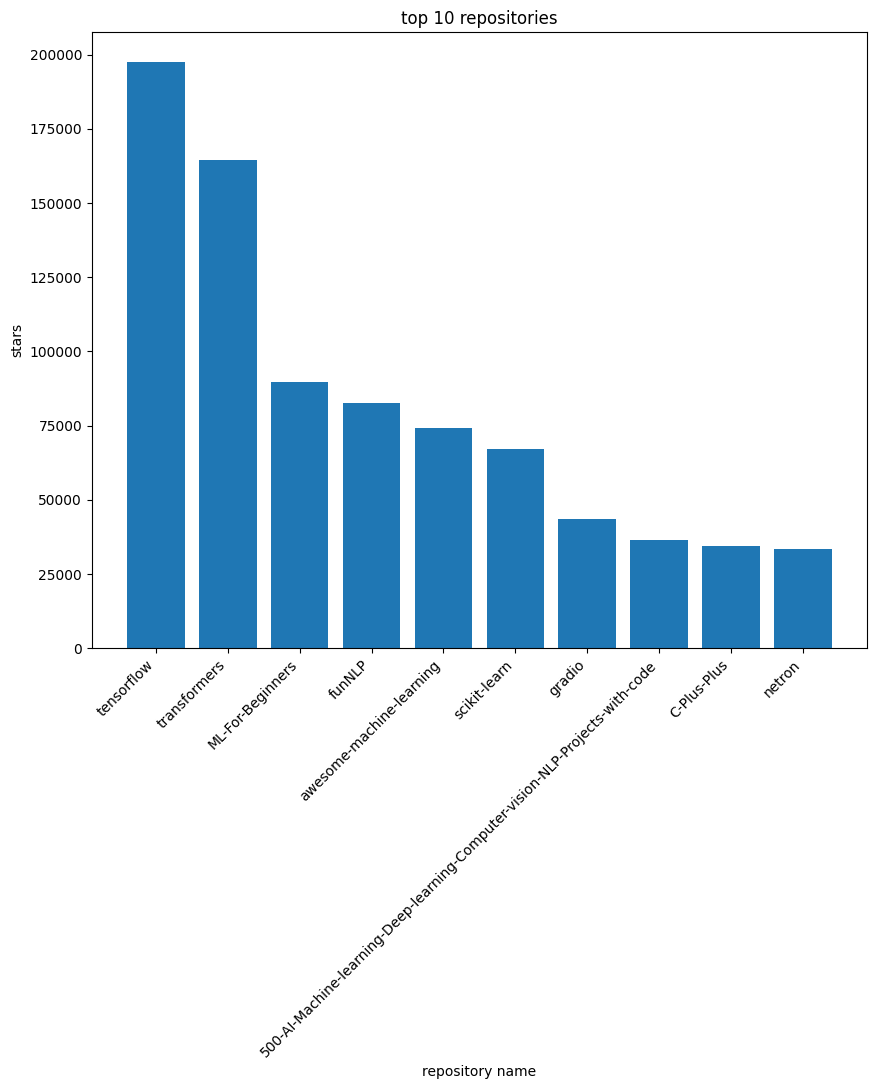

In [574]:
plt.figure(figsize=(10, 8))
plt.bar(top_10["name"], top_10["stars"])
plt.xlabel("repository name")
plt.ylabel("stars")
plt.title("top 10 repositories")
plt.xticks(rotation=45, ha="right")
plt.show()

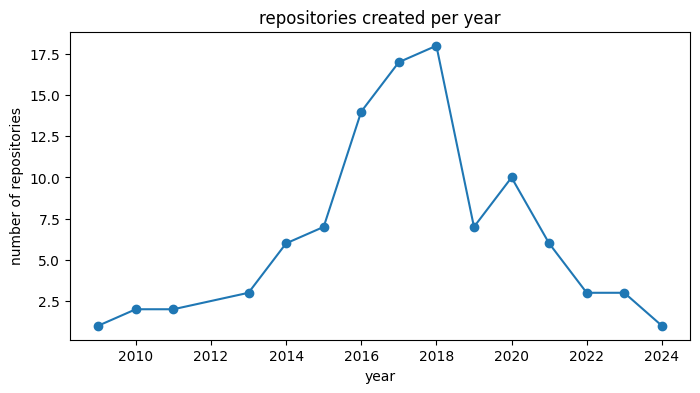

In [575]:
check_df["year"] = pd.to_datetime(check_df["created_date"]).dt.year
trend = check_df.groupby("year").size()

plt.figure(figsize=(8, 4))
plt.plot(trend.index, trend.values, marker="o")
plt.xlabel("year")
plt.ylabel("number of repositories")
plt.title("repositories created per year")
plt.show()

# **Interpreting the results:**
Most popular projects: Python projects like ***tensorflow*** and ***transformers*** are the most popular and have the highest number of stars.

Creation trends: The creation of machine learning projects increased rapidly between ***2016 and 2018***.

# **Ethical Reflections**

***Question 1*** : Why is it important to verify data collected from public APIs?

- To ensure data accuracy, up-to-dateness, and the absence of missing or corrupted fields before analysis begins.

***Question 2*** : Why should data analysts document their data sources?

- To maintain transparency, build trust, and enable anyone to easily verify the figures or replay the code.

***Question 3*** : How can missing or inaccurate data affect data analysis and decision-making?

- It leads to biased and erroneous results, causing poor business decisions based on incorrect information.